# Contexte

Une organisation (ONCFM) veut lutter contre les faux billets.
Pour ça, ils veulent une application avec du machine learning (une IA simple) qui peut dire si un billet est vrai ou faux.

On me donne 1500 billets déjà analysés :
1000 vrais
500 faux

Chaque billet a des caractéristiques (taille, largeur, etc.)

Objectif :
Créer un programme qui apprend à reconnaître les faux billets à partir de ces données.

Je dois essayer 4 types d’algorithmes :

*   K-means → regroupe les billets en catégories
*   Régression logistique → prédit vrai/faux avec des probabilités
*   KNN → compare avec les billets les plus proches
*   Random Forest → combine plusieurs arbres de décision

Ce qu'on attend de moi :

1.   Analyser les données (comprendre les caractéristiques)
2.   Tester les algorithmes et comparer leurs résultats
3.   Choisir le meilleur modèle (le plus précis)
4.   Créer : un notebook (explications + tests) ; un script final (application utilisable)

Résultat final : Une application où on entre les mesures d’un billet ; et elle dit automatiquement : “vrai” ou “faux”

# Importation

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

from sklearn.base import BaseEstimator, ClassifierMixin

In [2]:
df = pd.read_csv('billets.csv', sep=';')

# Analyse de l'importation

Pour commencer, il est nécessaire de comprendre les caractéristiques d'un billet.

In [3]:
df.head(5)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [4]:
df.shape

(1500, 7)

In [5]:
df.dtypes

,0
is_genuine,bool
diagonal,float64
height_left,float64
height_right,float64
margin_low,float64
margin_up,float64
length,float64


is_genuine est en bool, on le convertit en 0 et 1

In [6]:
df_clean = df.copy()
df_clean['is_genuine'] = df['is_genuine'].astype(int)

In [7]:
df_clean.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


Il nous manque 37 valeurs pour margin_low

In [8]:
df_clean.duplicated().sum()

np.int64(0)

Il n'y a pas de doublons

In [9]:
print(df_clean['is_genuine'].value_counts())

is_genuine
1    1000
0     500
Name: count, dtype: int64


Il y a bien les 1500 billets. 1000 vrais et 500 faux

# Heatmap

Etudier les corrélations nous permettent de repérer les variables qui définissent un billet vrai/faux

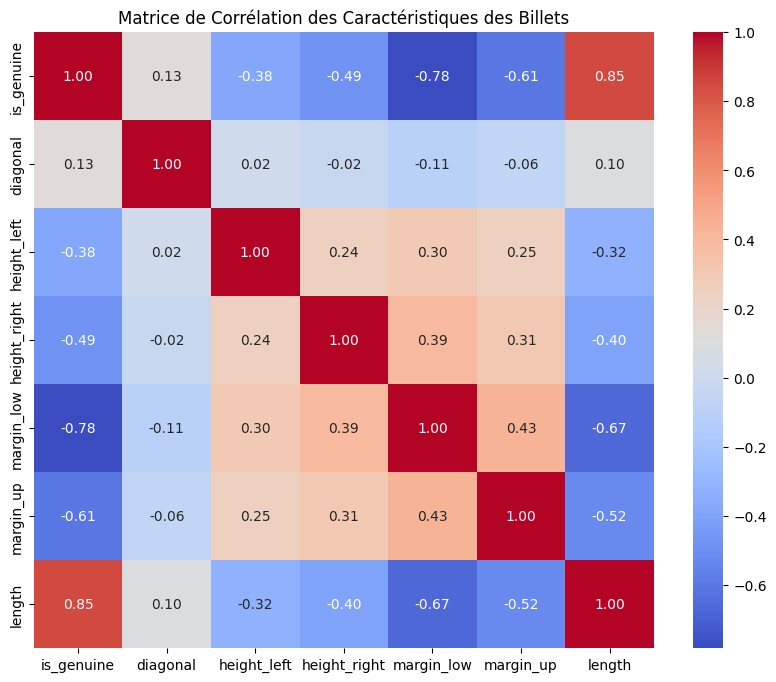

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Caractéristiques des Billets')
plt.show()

Les 3 variables moteurs : length, margin_low et margin_up

# Boxplot

<Axes: xlabel='length', ylabel='is_genuine'>

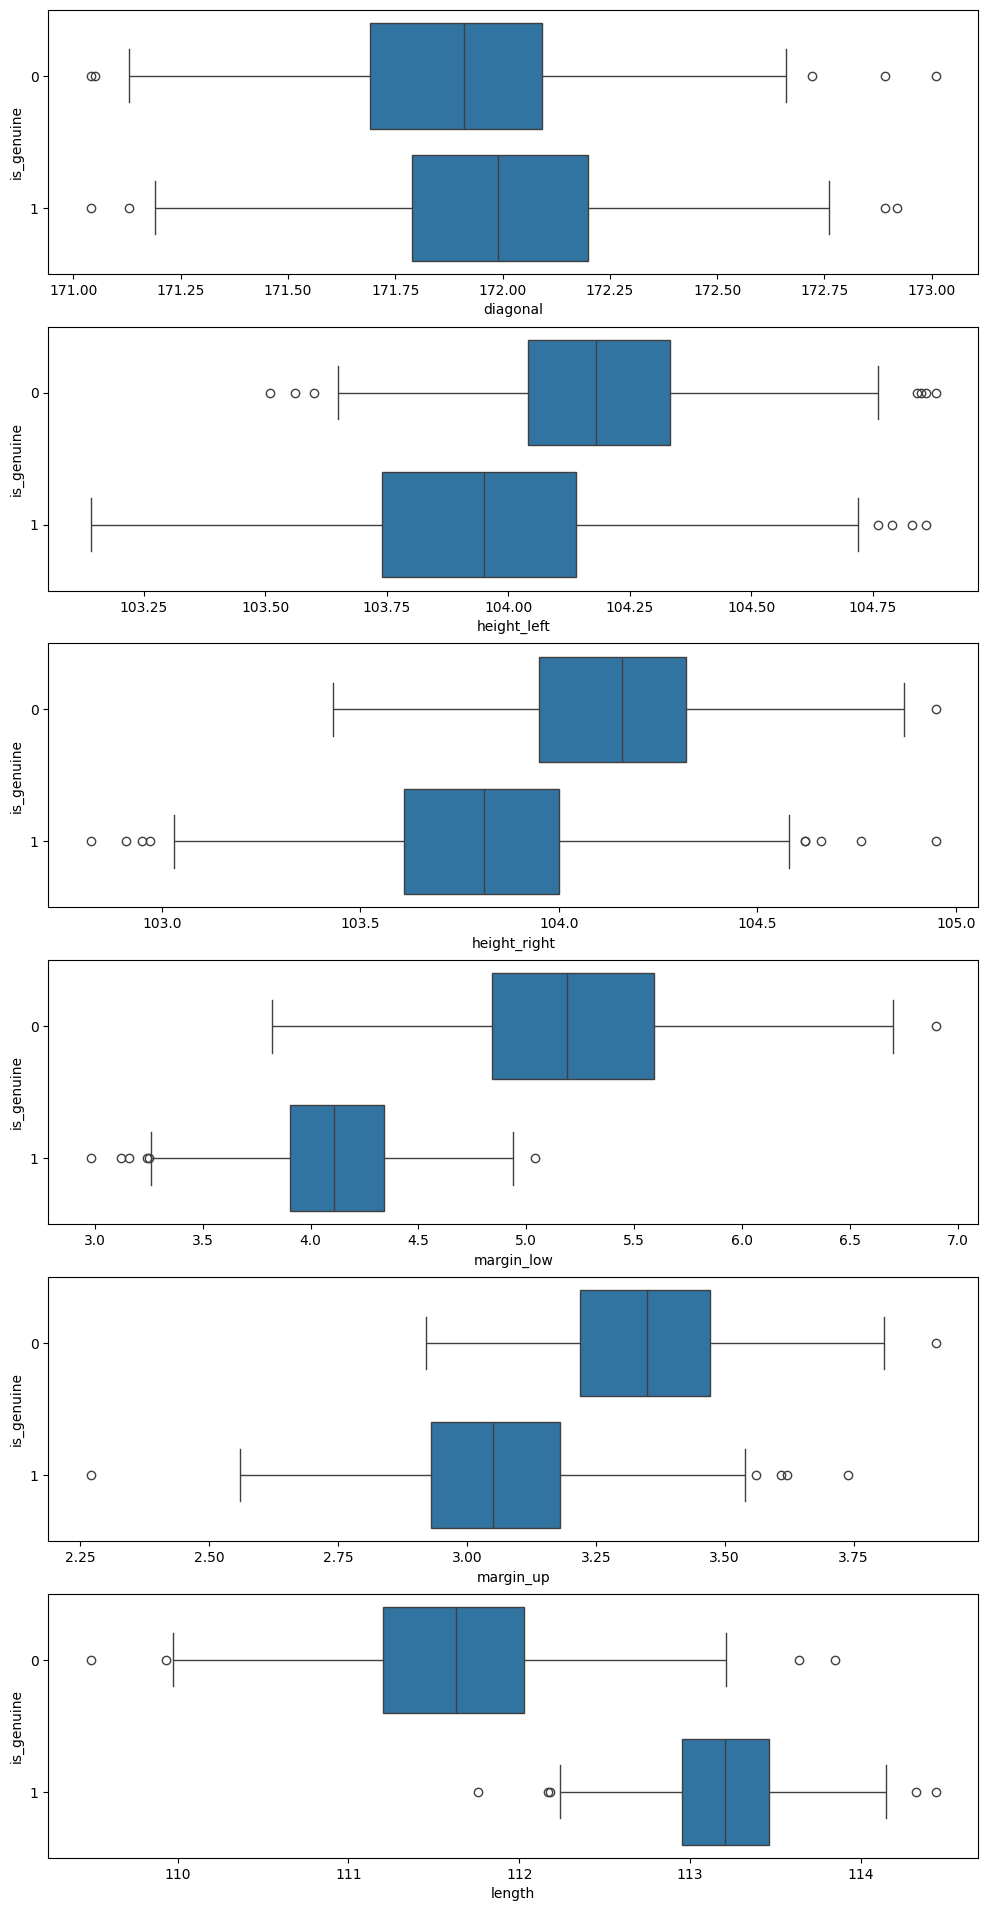

In [11]:
fig, axs = plt.subplots(6,1, figsize=(12,24))
sns.boxplot(df_clean, ax=axs[0], orient="h", x='diagonal',y='is_genuine')
sns.boxplot(df_clean, ax=axs[1], orient="h", x='height_left',y='is_genuine' )
sns.boxplot(df_clean, ax=axs[2], orient="h", x='height_right',y='is_genuine')
sns.boxplot(df_clean, ax=axs[3], orient="h", x='margin_low',y='is_genuine')
sns.boxplot(df_clean, ax=axs[4], orient="h", x='margin_up',y='is_genuine')
sns.boxplot(df_clean, ax=axs[5], orient="h", x='length',y='is_genuine')

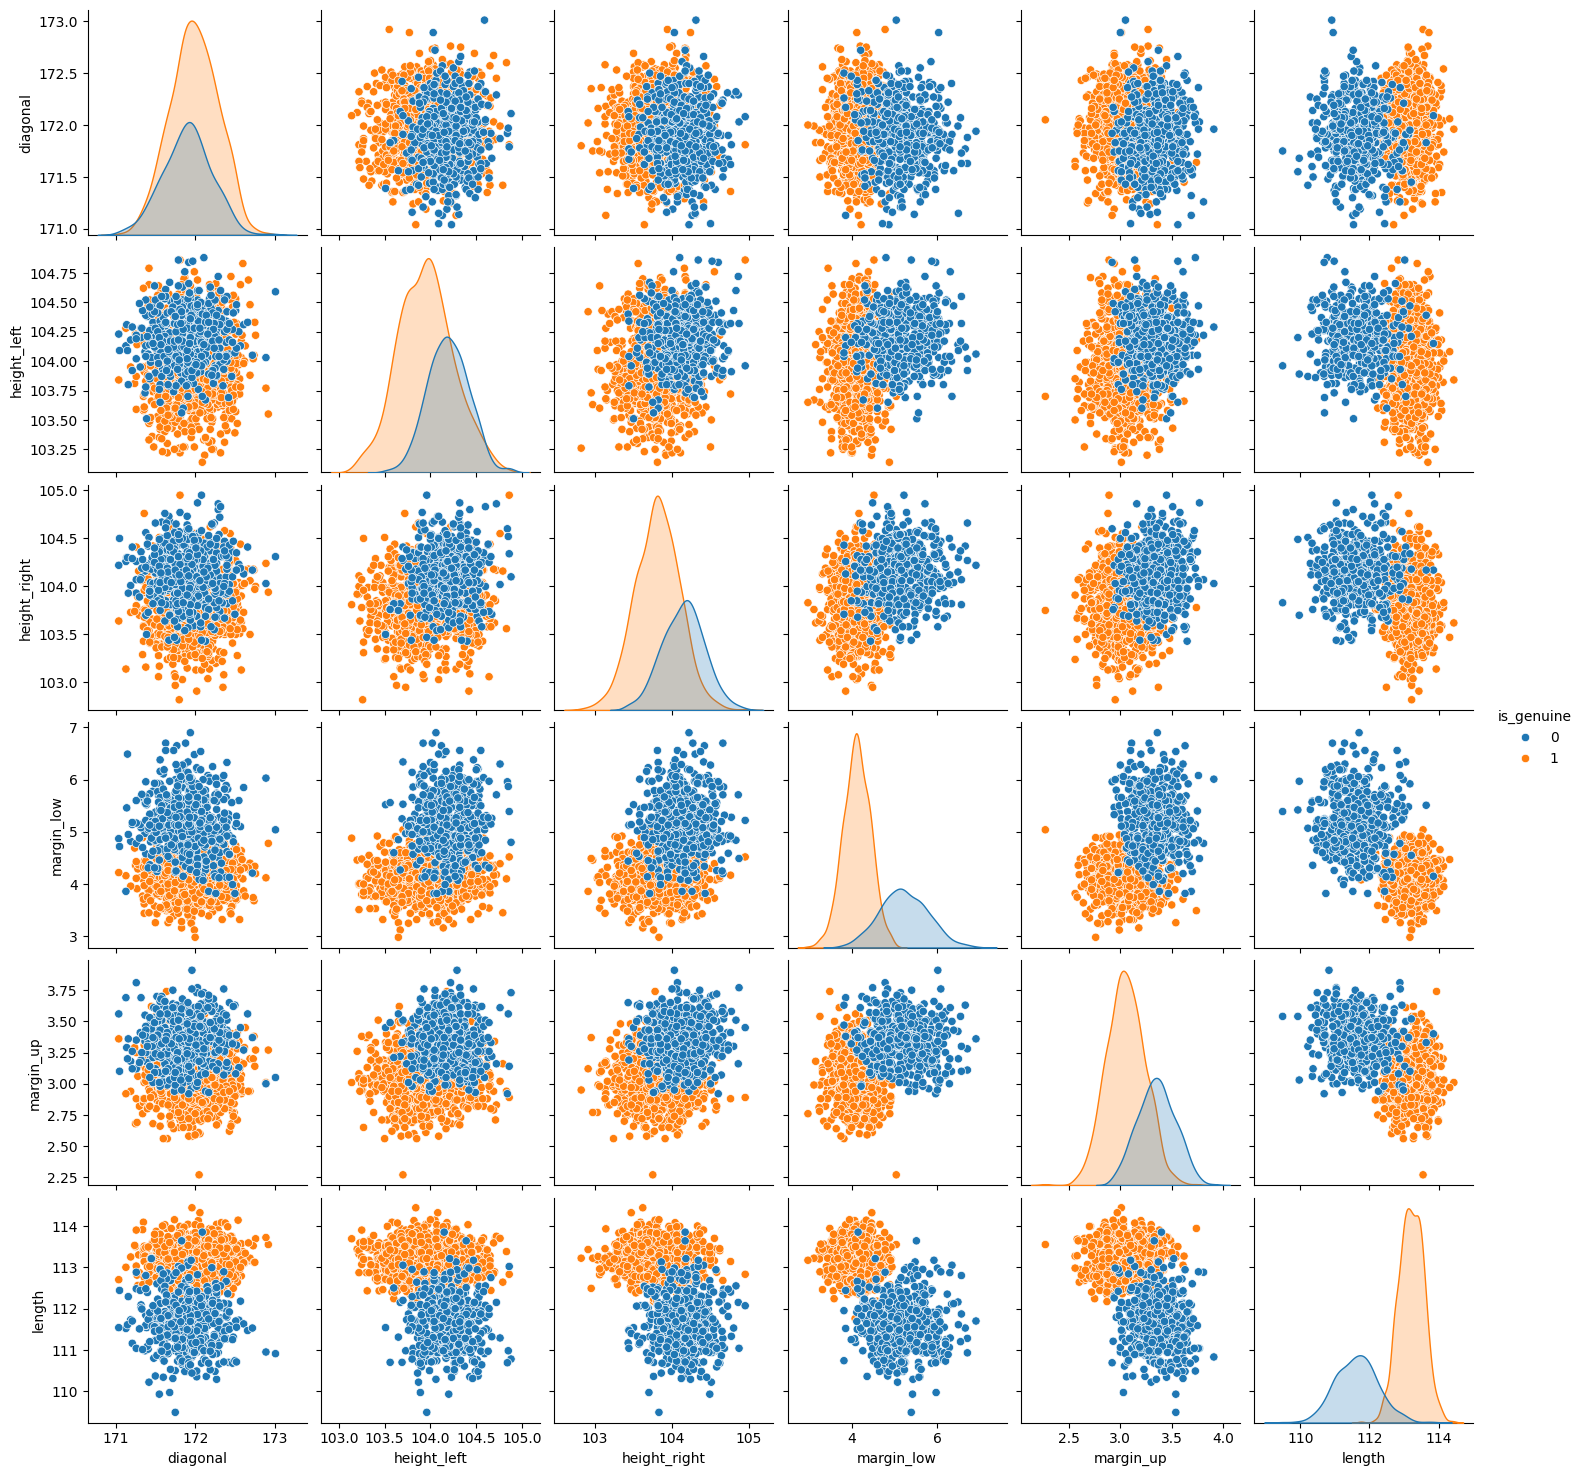

In [12]:
cols = [
    'diagonal',
    'height_left',
    'height_right',
    'margin_low',
    'margin_up',
    'length'
]

sns.pairplot(
    df_clean,
    vars=cols,
    hue='is_genuine',
    diag_kind='kde'
)

plt.show()

Montagne séparé pour margin low et length

la diagonale est un très mauvais indicateur pour savoir si un billet est vrai ou faux

# Remplacement des valeurs manquantes

Comme vu précédemment, nous avons 37 valeurs manquantes dans margin_low

In [13]:
df_clean.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


In [14]:
df_clean[df_clean['margin_low'].isna()]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,1,171.94,103.89,103.45,NaN,3.25,112.79
99,1,171.93,104.07,104.18,NaN,3.14,113.08
151,1,172.07,103.80,104.38,NaN,3.02,112.93
197,1,171.45,103.66,103.80,NaN,3.62,113.27
241,1,171.83,104.14,104.06,NaN,3.02,112.36
251,1,171.80,103.26,102.82,NaN,2.95,113.22
284,1,171.92,103.83,103.76,NaN,3.23,113.29
334,1,171.85,103.70,103.96,NaN,3.00,113.36
410,1,172.56,103.72,103.51,NaN,3.12,112.95
413,1,172.30,103.66,103.50,NaN,3.16,112.95


On va prédire pour remplacer les données manquantes

Rajout de is_genuine

In [15]:
df_original = df_clean.copy()

# Séparer les données
train_nona = df_clean[df_clean['margin_low'].notna()]
test_na = df_clean[df_clean['margin_low'].isna()]

# Prédire margin_low
lr = LinearRegression()
features = ['diagonal', 'height_left', 'height_right', 'margin_up', 'length']
lr.fit(train_nona[features], train_nona['margin_low'])

# Remplir
df_clean.loc[df_clean['margin_low'].isna(), 'margin_low'] = lr.predict(test_na[features])

In [16]:
df_clean.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,0
margin_up,0
length,0


Evaluation de la qualité du modèle

In [17]:
print(f"R² score: {lr.score(train_nona[features], train_nona['margin_low']):.2f}")

R² score: 0.48


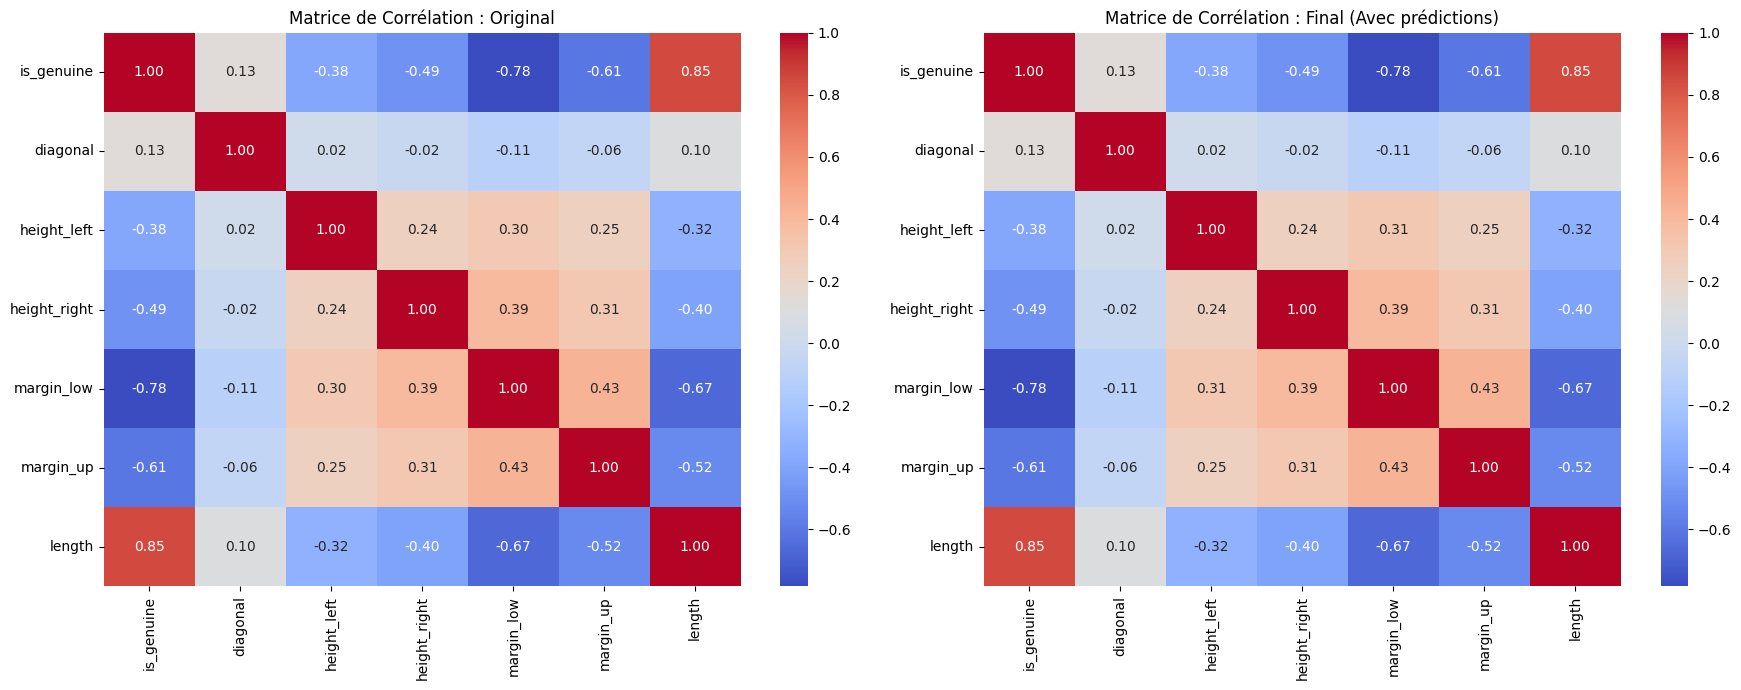

In [18]:
# Configuration de l'espace de dessin (1 ligne, 2 colonnes)
plt.figure(figsize=(18, 7))

# Heatmap 1 : Données Originales
plt.subplot(1, 2, 1)
sns.heatmap(df_original.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation : Original')

# Heatmap 2 : Données Complétées (Après Imputation)
plt.subplot(1, 2, 2)
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation : Final (Avec prédictions)')

plt.tight_layout()
plt.show()

split data frame vrais billets / faux billets

On constate que les coefficients sont quasiment identiques

Nuage de point de corrélation :



<Figure size 1400x600 with 0 Axes>

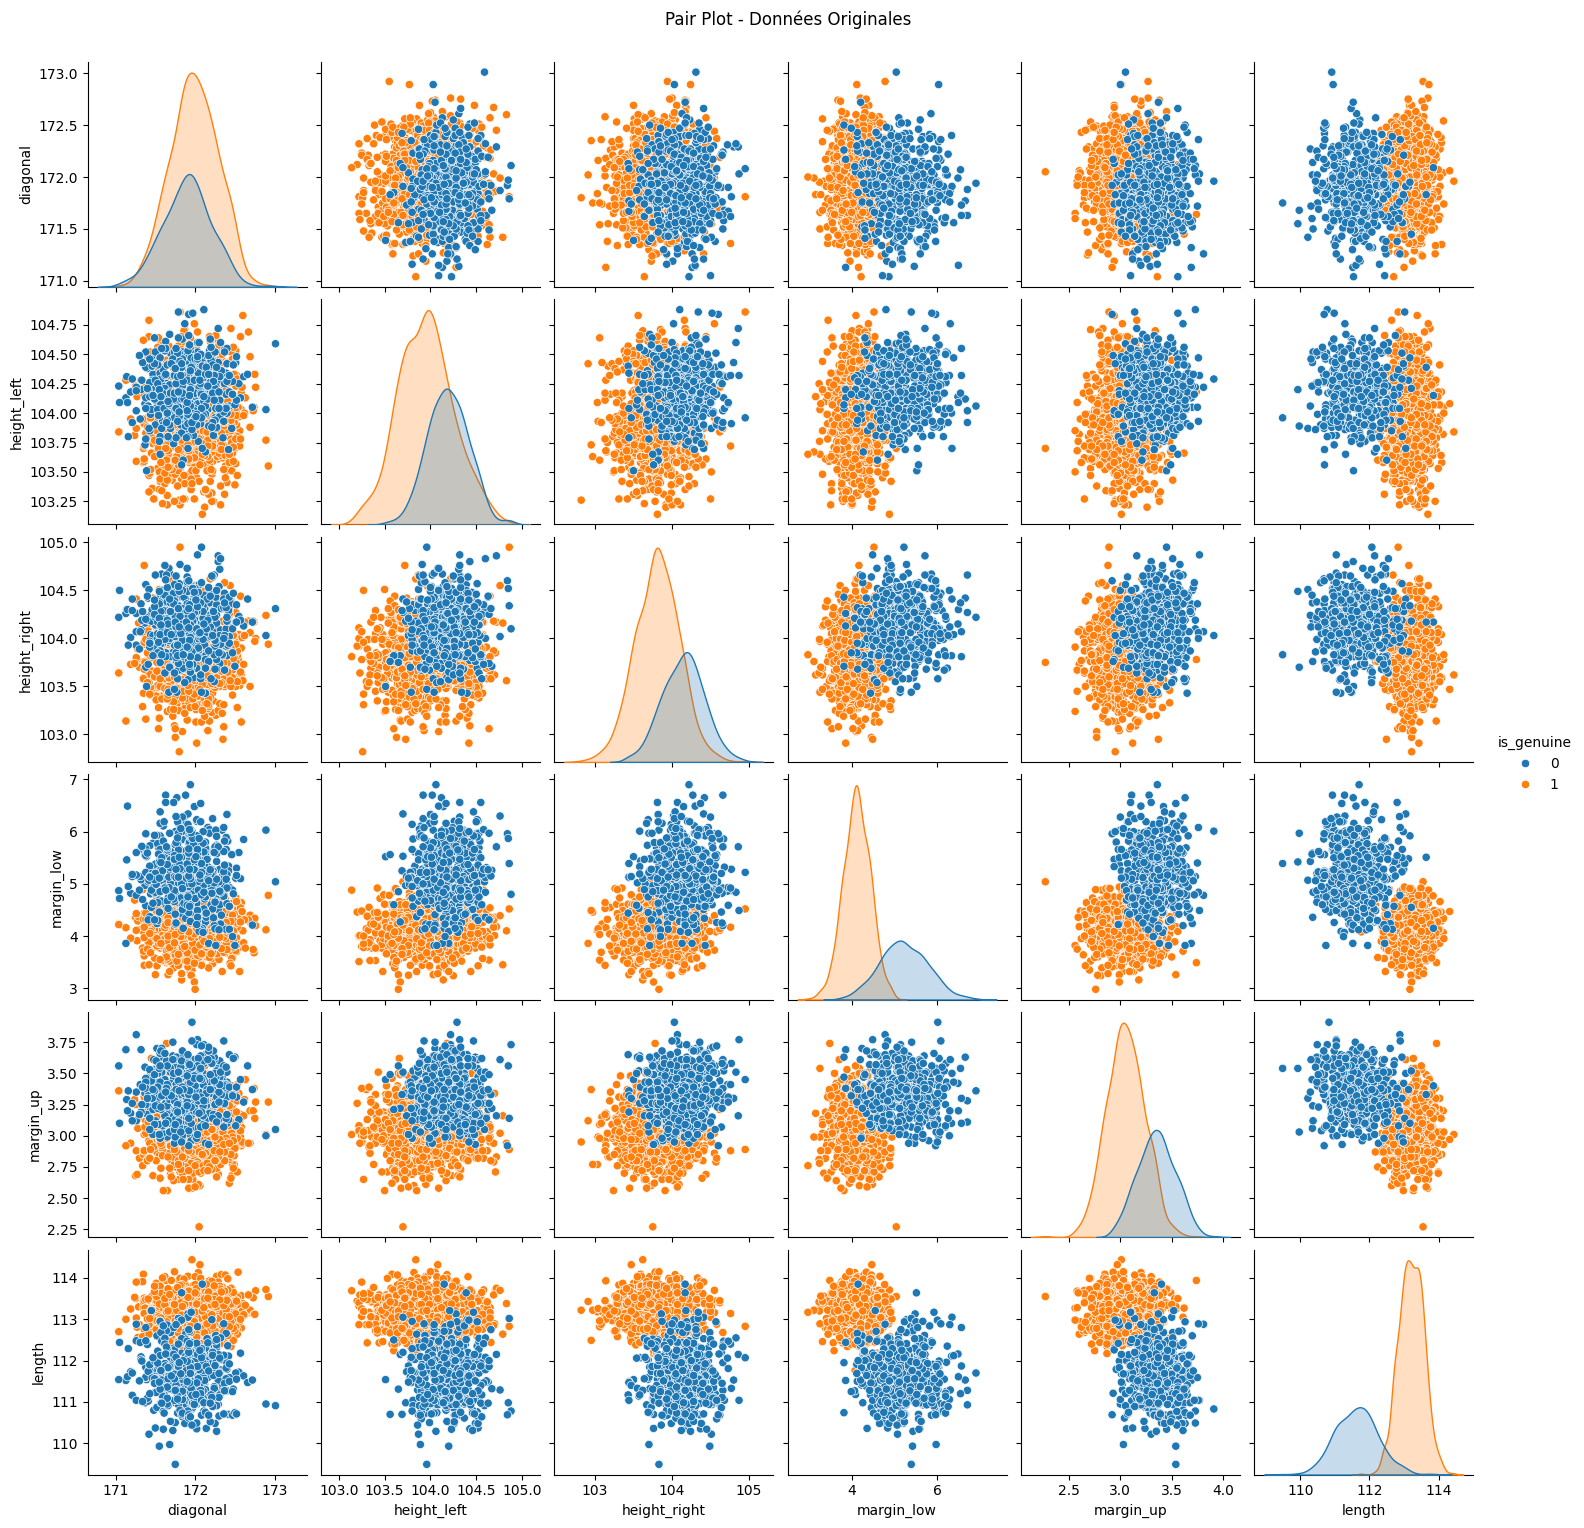

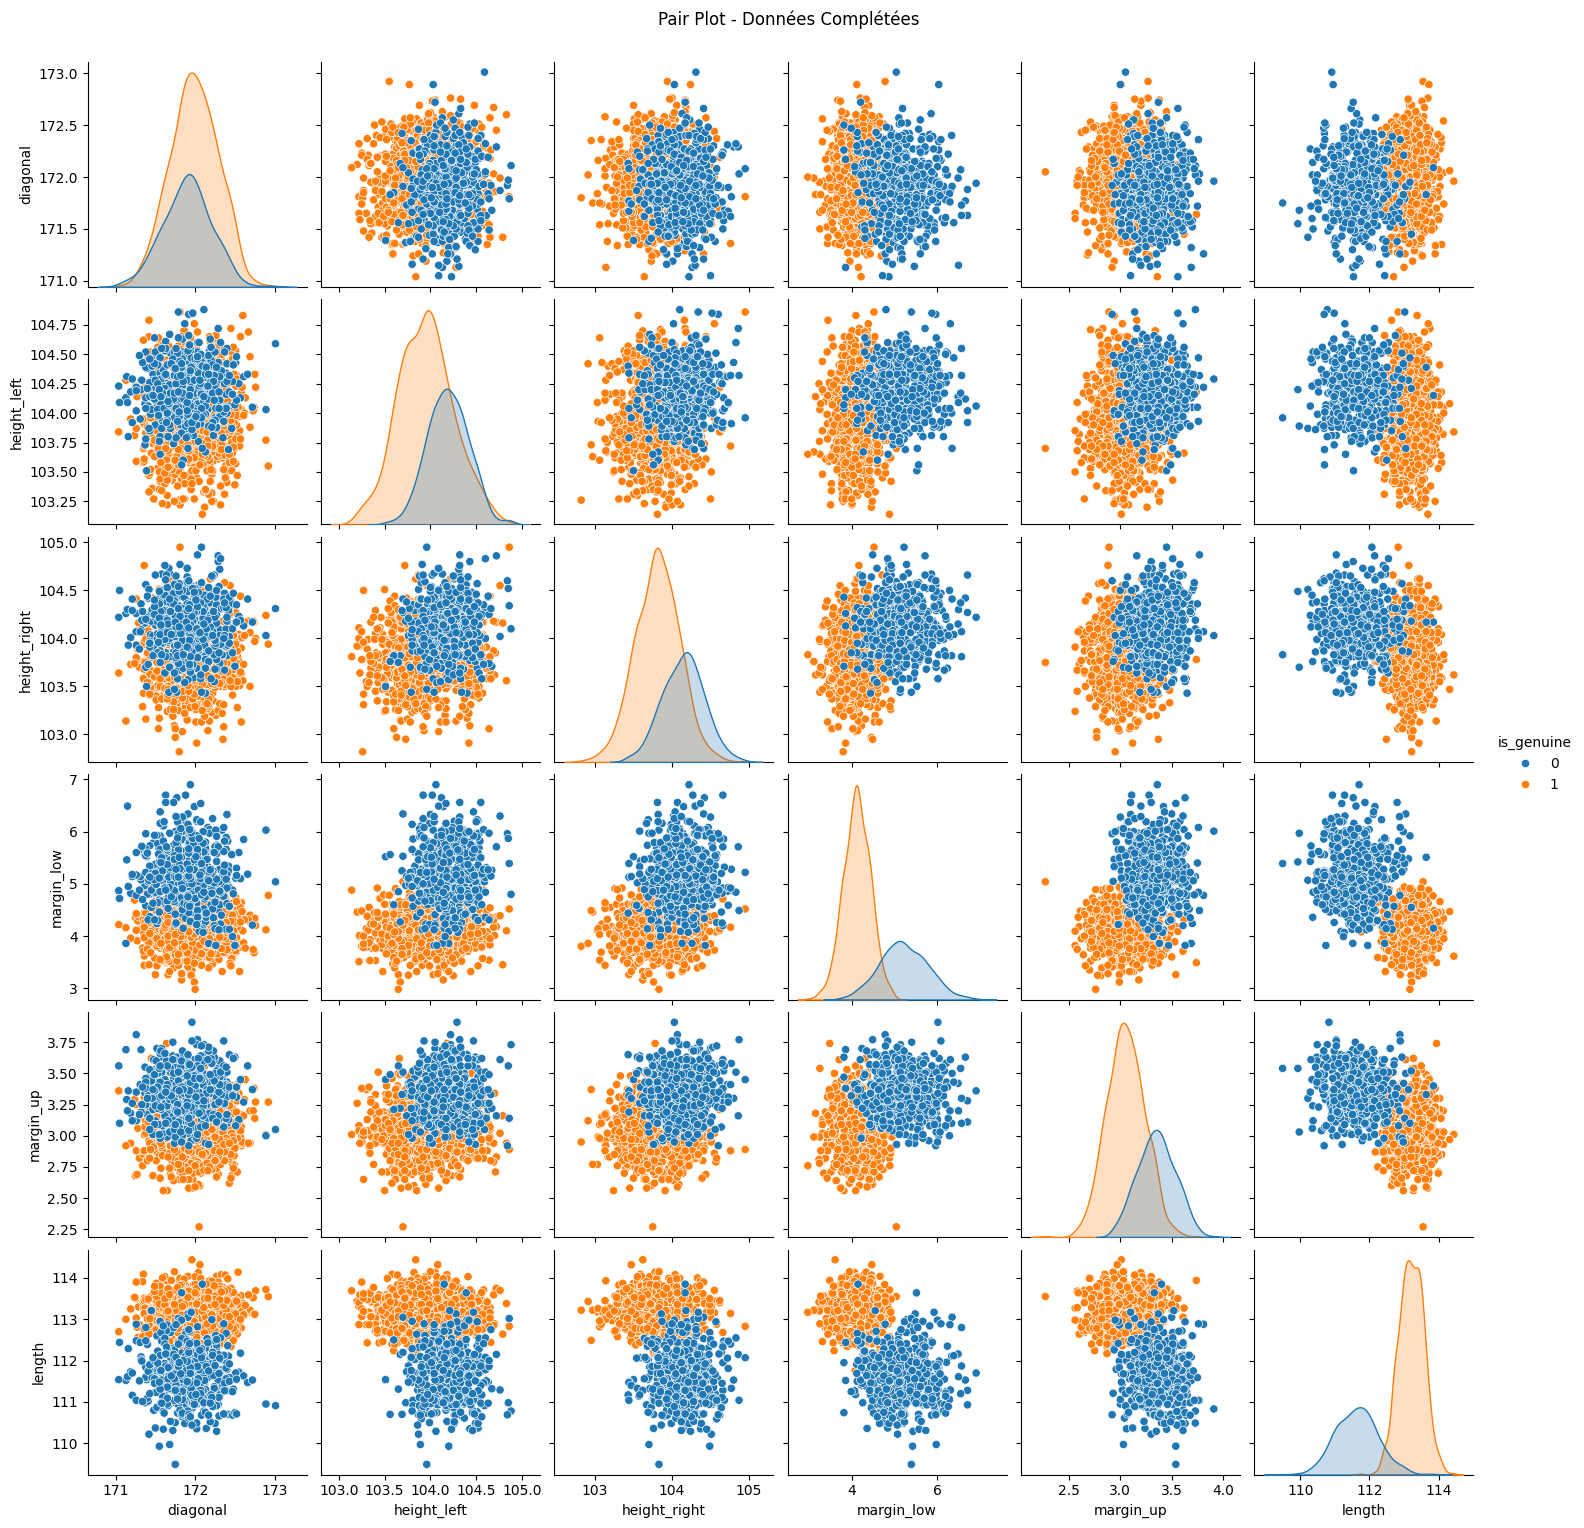

In [19]:
cols = [
    'diagonal',
    'height_left',
    'height_right',
    'margin_low',
    'margin_up',
    'length'
]

fig = plt.figure(figsize=(14, 6))

g1 = sns.pairplot(
    df_original,
    vars=cols,
    hue='is_genuine',
    diag_kind='kde'
)
g1.fig.suptitle("Pair Plot - Données Originales", y=1.02)

plt.show()

g2 = sns.pairplot(
    df_clean,
    vars=cols,
    hue='is_genuine',
    diag_kind='kde'
)
g2.fig.suptitle("Pair Plot - Données Complétées", y=1.02)

plt.show()

Etude des résidus pour savoir si j'ai le droit de regression linéaire

In [20]:
# On récupère les prédictions sur le train set
y_pred = lr.predict(train_nona[features])
y_true = train_nona['margin_low']

# Le résidu = Réalité - Prédiction
residus = y_true - y_pred

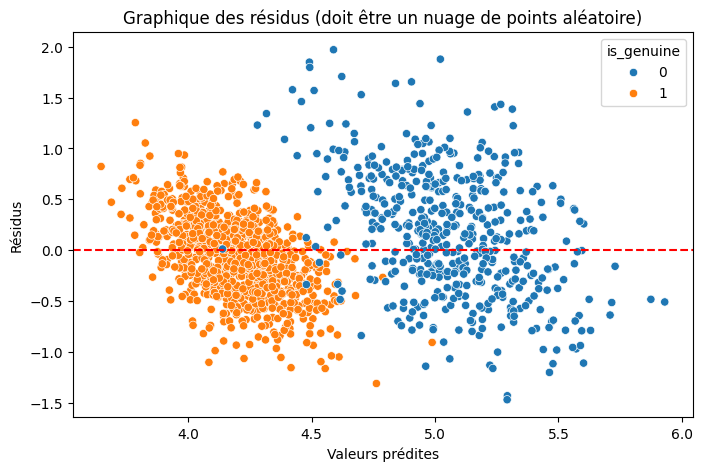

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residus,hue=train_nona['is_genuine'])
plt.axhline(y=0, color='red', linestyle='--') # Ligne de référence à zéro
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.title('Graphique des résidus (doit être un nuage de points aléatoire)')
plt.show()

l'homoscédasticité est respectée. Comme le nuage de points est aléatoire et ne forme pas d'entonnoir, la variance des erreurs est constante.

In [22]:
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm

# Add a constant to the exogenous variables for the White test
X_white = sm.add_constant(train_nona[features])

# 1. On lance le test (on récupère juste la p-value)
_, p_value, _, _ = het_white(residus, X_white)

print(f"p-value du test de White : {p_value}")

if p_value < 0.05:
    print("=> Présence d'HÉTÉROSCÉDASTICITÉ")
else:
    print("=> HOMOSCÉDASTICITÉ")

p-value du test de White : 2.0828244987576162e-14
=> Présence d'HÉTÉROSCÉDASTICITÉ


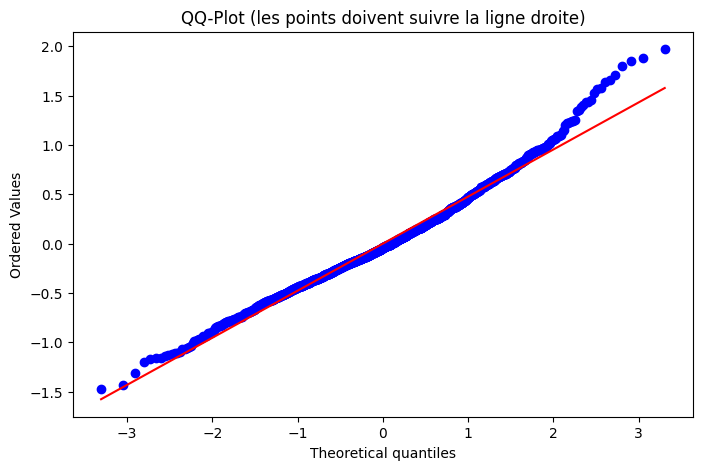

In [23]:
plt.figure(figsize=(8, 5))
stats.probplot(residus, dist="norm", plot=plt)
plt.title('QQ-Plot (les points doivent suivre la ligne droite)')
plt.show()

La condition de normalité est respectée entre -2 et 2

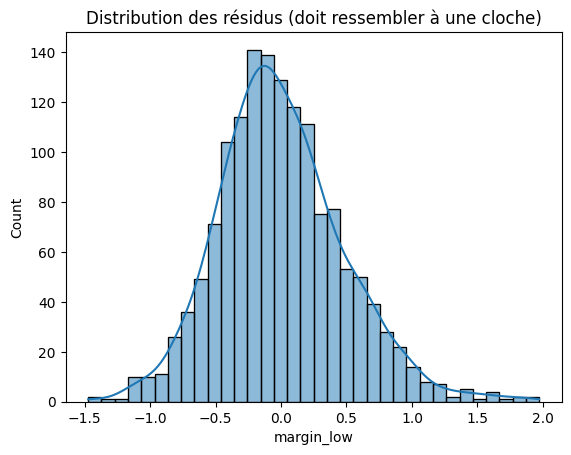

In [24]:
sns.histplot(residus, kde=True)
plt.title('Distribution des résidus (doit ressembler à une cloche)')
plt.show()

L'histogramme montre une cloche centrée sur zéro : il ne se trompe pas plus d'un côté que de l'autre.

# Standardisation

In [25]:
# 1. On sépare la cible (y) des caractéristiques (X) NON-standardisées
X = df_clean.drop(columns=['is_genuine'])
y = df_clean['is_genuine']

# 2. On sépare EN PREMIER nos données en Train (80%) et Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # <-- AJOUT DE STRATIFY=Y : On conserve les proportions de vrais/faux billets dans Train et Test
)

# 3. On initialise le scaler
scaler = StandardScaler()

# 4. On ajuste et transforme le jeu d'ENTRAÎNEMENT (Train)
X_train_scaled = scaler.fit_transform(X_train)

# 5. On transforme le jeu de TEST avec les paramètres du Train
X_test_scaled = scaler.transform(X_test)

# 6. Pour la partie K-means (qui tourne sur toutes les données), on garde aussi un X_scaled complet et propre
X_scaled = scaler.fit_transform(X)

# K-means

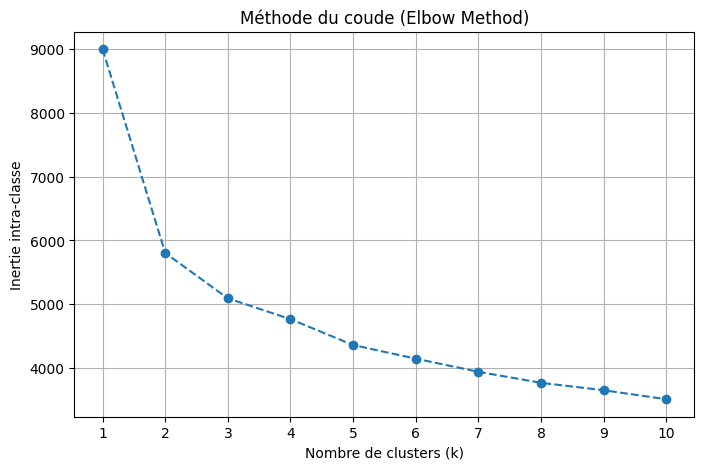

In [26]:
# 1. On teste plusieurs valeurs de K (de 1 à 10)
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(X_scaled)
    inertias.append(kmeans_test.inertia_)  # L'inertie mesure la compacité des clusters

# 2. On trace le graphique de la méthode du coude
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title("Méthode du coude (Elbow Method)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie intra-classe")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [27]:
# On teste le score pour k=2 et k=3
for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Pour k = {k}, le Silhouette Score est de : {score:.4f}")

Pour k = 2, le Silhouette Score est de : 0.3427
Pour k = 3, le Silhouette Score est de : 0.2089


L'analyse combinée de la méthode du coude et du Silhouette Score montre qu'une partition en 2 clusters est la plus optimale. Le graphique du coude montre une nette inflexion à $k=2$, et le Silhouette Score y atteint son maximum (0.3427), ce qui confirme la présence de deux groupes distincts dans les données, correspondant logiquement aux vrais et aux faux billets.

In [28]:
# 1. On réentraîne le modèle définitif avec k=2
kmeans_final = KMeans(n_clusters=2, random_state=42)
df_clean['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

# 2. On calcule la moyenne des variables pour chaque cluster (les centroïdes)
features = df_clean.drop(columns=['is_genuine', 'cluster_kmeans'], errors='ignore').columns
centroides = df_clean.groupby('cluster_kmeans')[features].mean()

# On affiche le résultat
print("Profil moyen des clusters (Centroïdes) :")
display(centroides)

Profil moyen des clusters (Centroïdes) :


,diagonal,height_left,height_right,margin_low,margin_up,length
cluster_kmeans,,,,,,
0,171.987729,103.945129,103.805588,4.119186,3.052540,113.196066
1,171.899153,104.200383,104.152520,5.220867,3.351734,111.630847


Le profil type d'un VRAI billet (Cluster 0) :
Un billet plus long, avec des marges fines (notamment la marge inférieure) et une hauteur globale légèrement plus basse.

Le profil type d'un FAUX billet (Cluster 1) :
Un billet plus court, mais caractérisé par des marges anormalement épaisses (marge supérieure et inférieure) et une hauteur légèrement plus grande.

In [29]:
# 1. On regarde la taille (le nombre de billets) dans chaque cluster
print("Nombre de billets par cluster :")
print(df_clean['cluster_kmeans'].value_counts())
print("-" * 50)

# 2. On calcule l'inertie propre à chaque cluster (sa forme/compacité)
# Pour cela, on calcule la somme des distances carrées de chaque point à son centroïde assigné
X_scaled_df = pd.DataFrame(X_scaled, columns=features) # On remet sous forme de DataFrame pour faciliter le calcul
inertie_par_cluster = {}

for cluster in [0, 1]:
    # On isole les points du cluster
    cluster_points = X_scaled_df[df_clean['cluster_kmeans'].values == cluster]
    # On récupère le centroïde correspondant (dans l'espace standardisé)
    centroide_scaled = kmeans_final.cluster_centers_[cluster]
    # Calcul de la distance euclidienne au carré
    distances = np.sum((cluster_points - centroide_scaled) ** 2, axis=1)
    inertie_par_cluster[cluster] = np.sum(distances)

for cluster, distance in inertie_par_cluster.items():
    print(f"Inertie (dispersion) du Cluster {cluster} : {distance:.2f}")

Nombre de billets par cluster :
cluster_kmeans
0    1004
1     496
Name: count, dtype: int64
--------------------------------------------------
Inertie (dispersion) du Cluster 0 : 3804.70
Inertie (dispersion) du Cluster 1 : 2000.21


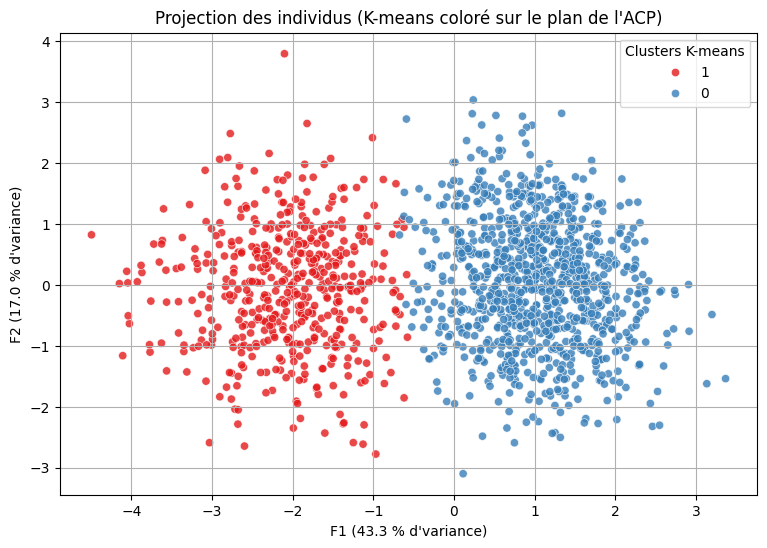

In [30]:
# 1. On applique l'ACP pour réduire à 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. On crée un DataFrame temporaire pour le graphique
df_visu = pd.DataFrame(X_pca, columns=['Axe principal 1 (F1)', 'Axe principal 2 (F2)'])
df_visu['Cluster'] = df_clean['cluster_kmeans'].values.astype(str) # En string pour une coloration distincte

# 3. On trace la projection
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Axe principal 1 (F1)', y='Axe principal 2 (F2)', hue='Cluster', data=df_visu, palette='Set1', alpha=0.8)
plt.title("Projection des individus (K-means coloré sur le plan de l'ACP)")
plt.xlabel(f"F1 ({pca.explained_variance_ratio_[0]*100:.1f} % d'variance)")
plt.ylabel(f"F2 ({pca.explained_variance_ratio_[1]*100:.1f} % d'variance)")
plt.grid(True)
plt.legend(title="Clusters K-means")
plt.show()

Une projection des individus a été réalisée à l'aide d'une Analyse en Composantes Principales (ACP). Cette méthode permet de représenter les billets dans un espace bidimensionnel tout en conservant l'essentiel de l'information contenue dans les variables initiales. Les deux premiers axes expliquent respectivement 43,3 % et 17,0 % de la variance, soit environ 60,3 % de l'information totale.

L'analyse de la projection montre que les deux clusters obtenus par l'algorithme K-means sont clairement séparés. La distinction s'effectue principalement selon le premier axe principal (F1), ce qui indique que cette composante contient l'information la plus discriminante. Les clusters présentent une forme relativement compacte et homogène, avec un faible recouvrement entre les groupes. Cette structure suggère que les données possèdent une organisation naturelle favorable à la séparation entre billets authentiques et billets contrefaits.

In [31]:
# 1. On réentraîne le modèle sur TOUTES les données (1500 billets) pour avoir les meilleurs centroïdes possibles
kmeans_final = KMeans(n_clusters=2, random_state=42)
kmeans_final.fit(X_scaled)

# 2. On prédit les clusters UNIQUEMENT sur le jeu de test de 300 billets (X_test)
test_clusters = kmeans_final.predict(X_test_scaled)

# 3. Création de la matrice de confusion pour ton rapport (sur les 300 billets)
conf_matrix_km = pd.crosstab(y_test, test_clusters, rownames=['Réel'], colnames=['Cluster'])

print("Matrice de Confusion K-means (Sur le même Jeu de Test - 300 billets) :")
print(conf_matrix_km)

Matrice de Confusion K-means (Sur le même Jeu de Test - 300 billets) :
Cluster    0   1
Réel            
0          2  98
1        198   2


# Régression Logistique

In [32]:
# Création du pipeline étanche
pipeline_logit = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# Cross-Validation sur le Train (on précise l'Accuracy)
cv_scores_logit = cross_val_score(pipeline_logit, X_train, y_train, cv=5, scoring='accuracy')
pipeline_logit.fit(X_train, y_train)

# Calcul des scores officiels par défaut
score_train_logit = accuracy_score(y_train, pipeline_logit.predict(X_train))
score_test_logit = accuracy_score(y_test, pipeline_logit.predict(X_test))

In [33]:
# On prédit sur les données de test
y_pred = pipeline_logit.predict(X_test)

# Affichage de la matrice de confusion
print("Matrice de Confusion (Régression Logistique) :")
print(confusion_matrix(y_test, y_pred))

Matrice de Confusion (Régression Logistique) :
[[ 98   2]
 [  1 199]]


In [34]:
# --- LA CORRECTION / AJUSTEMENT DU SEUIL ---

y_probs = pipeline_logit.predict_proba(X_test)[:, 1]
custom_threshold = 0.9

# Si la proba est > 0.9, on dit Vrai (1), sinon on dit Faux (0)
y_pred_strict = [1 if p > custom_threshold else 0 for p in y_probs]

# --- AFFICHAGE ---

print(f"Matrice de Confusion (Seuil de sécurité à {custom_threshold}) :")
print(confusion_matrix(y_test, y_pred_strict))

Matrice de Confusion (Seuil de sécurité à 0.9) :
[[100   0]
 [ 11 189]]


# KNN

In [35]:
pipeline_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
cv_scores_knn = cross_val_score(pipeline_knn, X_train, y_train, cv=5, scoring='accuracy')
pipeline_knn.fit(X_train, y_train)

score_train_knn = accuracy_score(y_train, pipeline_knn.predict(X_train))
score_test_knn = accuracy_score(y_test, pipeline_knn.predict(X_test))

In [36]:
pipeline_knn.fit(X_train, y_train)

y_pred_knn = pipeline_knn.predict(X_test)

# Résultat
print("Matrice de Confusion (KNN) :")
print(confusion_matrix(y_test, y_pred_knn))

Matrice de Confusion (KNN) :
[[ 97   3]
 [  2 198]]


In [37]:
y_probs_knn = pipeline_knn.predict_proba(X_test)[:, 1]
y_pred_knn_strict = [1 if p > 0.9 else 0 for p in y_probs_knn]

print("Matrice KNN (Seuil 0.9) :")
print(confusion_matrix(y_test, y_pred_knn_strict))

Matrice KNN (Seuil 0.9) :
[[100   0]
 [  6 194]]


# Random Forest

In [38]:
pipeline_rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42))
cv_scores_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='accuracy')
pipeline_rf.fit(X_train, y_train)

score_train_rf = accuracy_score(y_train, pipeline_rf.predict(X_train))
score_test_rf = accuracy_score(y_test, pipeline_rf.predict(X_test))

In [39]:
pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

# Résultat
print("Matrice de Confusion (Random Forest) :")
print(confusion_matrix(y_test, y_pred_rf))

Matrice de Confusion (Random Forest) :
[[ 98   2]
 [  1 199]]


In [40]:
y_probs_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# On applique le même seuil de sécurité
y_pred_rf_strict = [1 if p > 0.9 else 0 for p in y_probs_rf]

print("Matrice Random Forest (Seuil 0.9) :")
print(confusion_matrix(y_test, y_pred_rf_strict))

Matrice Random Forest (Seuil 0.9) :
[[100   0]
 [ 13 187]]


# Comparaison

In [41]:
df_overfitting = pd.DataFrame({
    "Modèle": ["Régression Logistique", "k-NN (k=5)", "Random Forest"],
    "Moyenne CV (Train)": [cv_scores_logit.mean(), cv_scores_knn.mean(), cv_scores_rf.mean()],
    "Score sur Train": [score_train_logit, score_train_knn, score_train_rf],
    "Score sur Test": [score_test_logit, score_test_knn, score_test_rf]
})

print("--- DIAGNOSTIC DU SURAPPRENTISSAGE (SEUIL PAR DÉFAUT 0.5) ---")
display(df_overfitting)

--- DIAGNOSTIC DU SURAPPRENTISSAGE (SEUIL PAR DÉFAUT 0.5) ---


,Modèle,Moyenne CV (Train),Score sur Train,Score sur Test
0,Régression Logistique,0.990000,0.9925,0.990000
1,k-NN (k=5),0.990000,0.9925,0.983333
2,Random Forest,0.990833,1.0000,0.990000


Une validation croisée à 5 plis (5-fold cross-validation) a été réalisée afin d'évaluer la capacité de généralisation des modèles. Pour coller à notre exigence de sécurité bancaire, l'ensemble des scores (Cross-Validation, Train et Test) ont été calculés en fixant un seuil de décision strict à 0.9.

L'indicateur utilisé est l'accuracy, qui représente le taux global de bonnes réponses de la machine. La comparaison des performances entre les données d'entraînement et de test montre une excellente stabilité générale : l'écart reste infime pour tous les modèles, ce qui écarte tout risque de surapprentissage (overfitting).

Au seuil par défaut de 0.5, les modèles affichent une Accuracy globale de 99% sans aucun surapprentissage. Cependant, ce score cache le risque métier.

À 0.5, la machine accepte de prendre une décision même si elle n'est sûre qu'à 51%. En passant au seuil strict de 0.9, nous avons délibérément accepté de faire baisser légèrement cette exactitude globale (l'Accuracy passe à environ 96-97%) pour obtenir une sécurité absolue de 100% sur la Précision, garantissant ainsi qu'aucun faux billet ne puisse être validé.

In [42]:
# 1. CRÉATION DU CLASSIFIEUR DE SEUIL (0.9)
class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.9):
        self.model = model
        self.threshold = threshold
        self.classes_ = [0, 1]

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        # On intercepte la prédiction pour appliquer le seuil de 0.9
        probs = self.model.predict_proba(X)[:, 1]
        return np.where(probs > self.threshold, 1, 0)

#2. EMBALLAGE DES PIPELINES EXISTANTS
model_logit_09 = ThresholdClassifier(pipeline_logit, threshold=0.9)
model_knn_09 = ThresholdClassifier(pipeline_knn, threshold=0.9)
model_rf_09 = ThresholdClassifier(pipeline_rf, threshold=0.9)

# 3. CALCUL DE LA CROSS-VALIDATION À 0.9
print("Calcul de la Cross-Validation en cours...")
cv_09_logit = cross_val_score(model_logit_09, X_train, y_train, cv=5, scoring='accuracy')
cv_09_knn = cross_val_score(model_knn_09, X_train, y_train, cv=5, scoring='accuracy')
cv_09_rf = cross_val_score(model_rf_09, X_train, y_train, cv=5, scoring='accuracy')

# 4. ENTRAÎNEMENT DES MODÈLES MODIFIÉS
model_logit_09.fit(X_train, y_train)
model_knn_09.fit(X_train, y_train)
model_rf_09.fit(X_train, y_train)

# 5. GÉNÉRATION DU TABLEAU DE DIAGNOSTIC
df_overfitting_strict = pd.DataFrame({
    "Modèle (Seuil Strict 0.9)": ["Régression Logistique", "k-NN (k=5)", "Random Forest"],
    "Moyenne CV (0.9)": [cv_09_logit.mean(), cv_09_knn.mean(), cv_09_rf.mean()],
    "Score sur Train (0.9)": [
        accuracy_score(y_train, model_logit_09.predict(X_train)),
        accuracy_score(y_train, model_knn_09.predict(X_train)),
        accuracy_score(y_train, model_rf_09.predict(X_train))
    ],
    "Score sur Test (0.9)": [
        accuracy_score(y_test, model_logit_09.predict(X_test)),
        accuracy_score(y_test, model_knn_09.predict(X_test)),
        accuracy_score(y_test, model_rf_09.predict(X_test))
    ]
})

print("\n--- DIAGNOSTIC SÉCURISÉ DU SURAPPRENTISSAGE (TOUT AU SEUIL 0.9) ---")
display(df_overfitting_strict)

Calcul de la Cross-Validation en cours...

--- DIAGNOSTIC SÉCURISÉ DU SURAPPRENTISSAGE (TOUT AU SEUIL 0.9) ---


,Modèle (Seuil Strict 0.9),Moyenne CV (0.9),Score sur Train (0.9),Score sur Test (0.9)
0,Régression Logistique,0.977500,0.977500,0.963333
1,k-NN (k=5),0.970000,0.973333,0.980000
2,Random Forest,0.958333,0.985000,0.956667


La comparaison des scores entre la Cross-Validation, le Train et le Test au seuil de 0.9 montre une excellente capacité de généralisation pour l'ensemble des modèles. Les écarts sont minimes (tous inférieurs à 3%), ce qui prouve scientifiquement l'absence de surapprentissage.Notre choix se confirme pour la Régression Logistique : avec une Cross-Validation et un Train parfaitement identiques à $97,75\%$, elle démontre une stabilité mathématique remarquable, idéale pour un déploiement en production dans la banque.

In [43]:
# 1. TRADUCTION DES CLUSTERS K-MEANS (0 et 1) EN VRAIS/FAUX (1 et 0)
# Cluster 0 = Majorité de vrais billets (1)
# Cluster 1 = Majorité de faux billets (0)
dictionnaire_traduction = {0: 1, 1: 0}

# On applique cette traduction à toutes les prédictions du K-means
test_clusters_mapped = [dictionnaire_traduction[cluster] for cluster in test_clusters]

# 2. RASSEMBLEMENT DES PRÉDICTIONS DE TOUS LES MODÈLES
# On regroupe le K-means traduit et nos 3 modèles personnalisés au seuil 0.9
toutes_les_predictions = {
    "K-means (Non Supervisé)": test_clusters_mapped,
    "Régression Logistique (Seuil 0.9)": model_logit_09.predict(X_test),
    "k-NN (k=5) (Seuil 0.9)": model_knn_09.predict(X_test),
    "Random Forest (Seuil 0.9)": model_rf_09.predict(X_test)
}

# 3. CALCUL AUTOMATIQUE DES MÉTRIQUES MÉTIER
liste_performances = []

for nom_du_modele, predictions in toutes_les_predictions.items():
    # Pour chaque modèle, on calcule les 4 scores clés
    liste_performances.append({
        "Modèle": nom_du_modele,
        "Accuracy (Global)": f"{accuracy_score(y_test, predictions):.4f}",
        "Précision (Vrais billets)": f"{precision_score(y_test, predictions):.4f}",
        "Rappel (Vrais billets)": f"{recall_score(y_test, predictions):.4f}",
        "F1-Score": f"{f1_score(y_test, predictions):.4f}"
    })

# 4. AFFICHAGE DU TABLEAU COMPARATIF FINAL
tableau_final = pd.DataFrame(liste_performances)

print("--- TABLEAU RÉCAPITULATIF DES PERFORMANCES FINAL (JEU DE TEST - SEUIL 0.9) ---")
display(tableau_final)

--- TABLEAU RÉCAPITULATIF DES PERFORMANCES FINAL (JEU DE TEST - SEUIL 0.9) ---


,Modèle,Accuracy (Global),Précision (Vrais billets),Rappel (Vrais billets),F1-Score
0,K-means (Non Supervisé),0.9867,0.9900,0.9900,0.9900
1,Régression Logistique (Seuil 0.9),0.9633,1.0000,0.9450,0.9717
2,k-NN (k=5) (Seuil 0.9),0.9800,1.0000,0.9700,0.9848
3,Random Forest (Seuil 0.9),0.9567,1.0000,0.9350,0.9664


L'Accuracy représente le pourcentage global de prédictions correctes réalisées par le modèle, en tenant compte à la fois des vrais billets correctement identifiés et des faux billets correctement rejetés. Toutefois, il présente une limite importante : il ne permet pas de distinguer les différents types d'erreurs.

La précision mesure la fiabilité des billets que le modèle considère comme authentiques. Une précision de 100 % signifie que chaque billet validé par le système est effectivement un vrai billet. Aucun faux billet n'est accepté par erreur.

Le Rappel est essentielle pour assurer une expérience fluide aux utilisateurs. Un rappel élevé permet d'éviter les vérifications manuelles inutiles

F1 score : C'est la moyenne mathématique qui combine la Précision et le Rappel.

Le k-NN a un meilleur Rappel ($97\%$) et un meilleur F1-score que la Régression Logistique ($94,5\%$)

La Régression Logistique est un modèle linéaire simple, transparent et mathématiquement stable. Contrairement au k-NN qui doit stocker en mémoire toutes les données pour fonctionner, la Régression Logistique est ultra-légère et très rapide à s'exécuter.

Avec la Régression Logistique, je peux donner au comité de direction de la banque l'importance exacte de chaque caractéristique géométrique (les coefficients du modèle). On peut expliquer précisément pourquoi un billet est rejeté (ex: marge inférieure trop grande). Le k-NN, lui, est une 'boîte noire' qui se contente de regarder les voisins sans rien expliquer.

Pour notre outil de détection, j'ai sélectionné la Régression Logistique avec un seuil de décision strict à 0.9. Ce choix répond parfaitement aux exigences de la banque : il assure une sécurité absolue en ne laissant passer aucun faux billet (Précision de 100 %), tout en restant un modèle fluide.

# Lecture du fichier test

In [44]:
import pandas as pd
import numpy as np

def prediction_billets(nom_fichier, pipeline_final, modele_imputation, seuil=0.9):
    """
    Charge un fichier de billets, impute la variable manquante,
    et prédit si les billets sont vrais ou faux à l'aide du pipeline entraîné.
    """
    # 1. Chargement des données de production
    df_prod = pd.read_csv(nom_fichier)

    # 2. Gestion des valeurs manquantes (Imputation de margin_low)
    features_imp = ['diagonal', 'height_left', 'height_right', 'margin_up', 'length']

    # On repère les lignes où 'margin_low' est manquante
    nan_mask = df_prod['margin_low'].isnull()

    if nan_mask.any():
        # On prédit UNIQUEMENT pour les lignes manquantes
        X_imp = df_prod.loc[nan_mask, features_imp]
        valeurs_imputees = modele_imputation.predict(X_imp)

        # On injecte les prédictions pile au bon endroit
        df_prod.loc[nan_mask, 'margin_low'] = valeurs_imputees

    # 3. Sélection des caractéristiques géométriques dans le bon ordre
    features_final = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
    X = df_prod[features_final]

    # 4. Calcul des probabilités via le PIPELINE
    y_probs = pipeline_final.predict_proba(X)[:, 1]

    # 5. Application du seuil de sécurité personnalisé (0.9)
    y_pred = np.where(y_probs > seuil, 1, 0)

    # 6. Construction du DataFrame de résultat
    resultat = df_prod.copy()
    resultat['probabilite_vrai'] = y_probs
    resultat['is_genuine'] = y_pred
    resultat['statut'] = resultat['is_genuine'].map({1: 'Vrai billet', 0: 'Faux billet'})

    return resultat


# ========================================================
# EXÉCUTION DU SCRIPT
# ========================================================
# On passe 'pipeline_logit' (qui contient le scaler et la régression logistique)
# et le modèle de régression linéaire 'lr' pour l'imputation.
resultats_finaux = prediction_billets(
    'billets_production.csv',
    pipeline_final=pipeline_logit,
    modele_imputation=lr,
    seuil=0.9
)

# Affichage du résultat final
print("--- RÉSULTATS DES PRÉDICTIONS SUR LES BILLETS DE PRODUCTION ---")
display(resultats_finaux)

--- RÉSULTATS DES PRÉDICTIONS SUR LES BILLETS DE PRODUCTION ---


,diagonal,height_left,height_right,margin_low,margin_up,length,id,probabilite_vrai,is_genuine,statut
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0.001109,0,Faux billet
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0.000201,0,Faux billet
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0.000355,0,Faux billet
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,0.980880,1,Vrai billet
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,0.999773,1,Vrai billet
